First 5 Rows
            State         Date Frequency  Unemployment_Rate  Employed  \
0  Andhra Pradesh   31-01-2020         M               5.48  16635535   
1  Andhra Pradesh   29-02-2020         M               5.83  16545652   
2  Andhra Pradesh   31-03-2020         M               5.79  15881197   
3  Andhra Pradesh   30-04-2020         M              20.51  11336911   
4  Andhra Pradesh   31-05-2020         M              17.43  12988845   

   Labour_Participation_Rate   Area  longitude  latitude  
0                      41.02  South    15.9129     79.74  
1                      40.90  South    15.9129     79.74  
2                      39.18  South    15.9129     79.74  
3                      33.10  South    15.9129     79.74  
4                      36.46  South    15.9129     79.74  

Dataset Shape: (267, 9)

Missing Values
State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     

<Figure size 800x500 with 0 Axes>

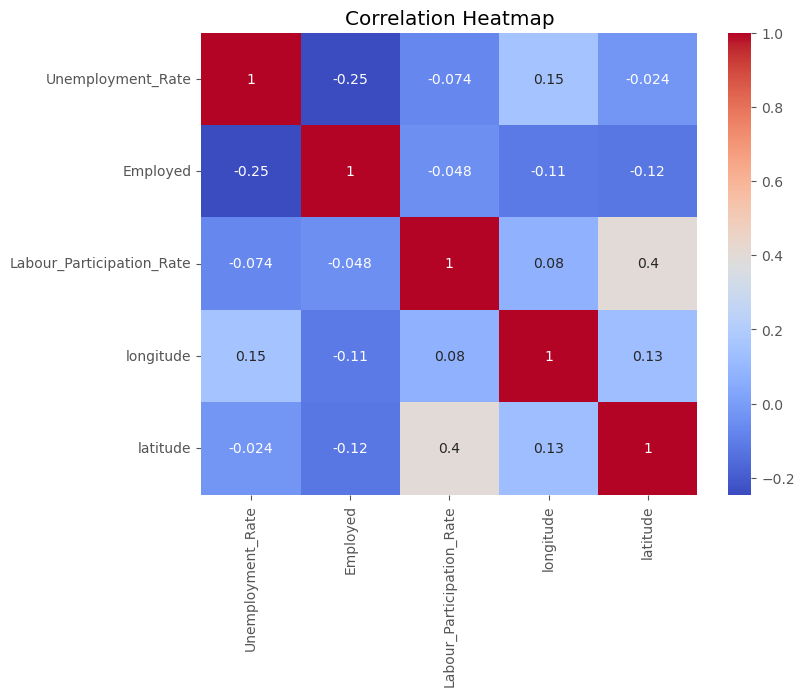

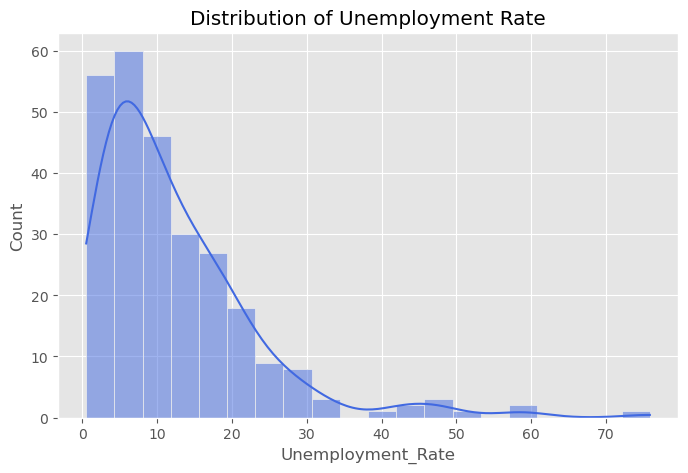

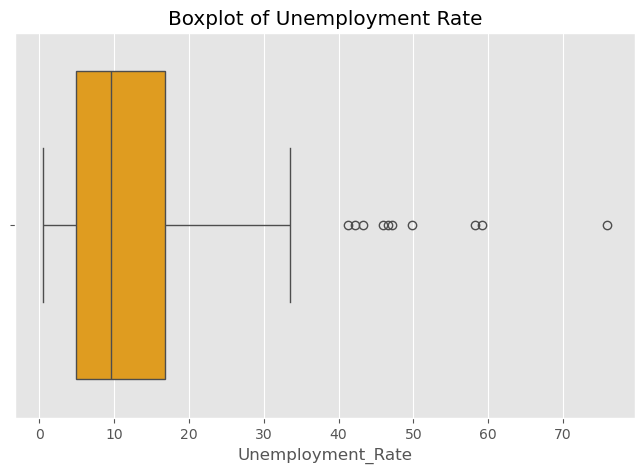

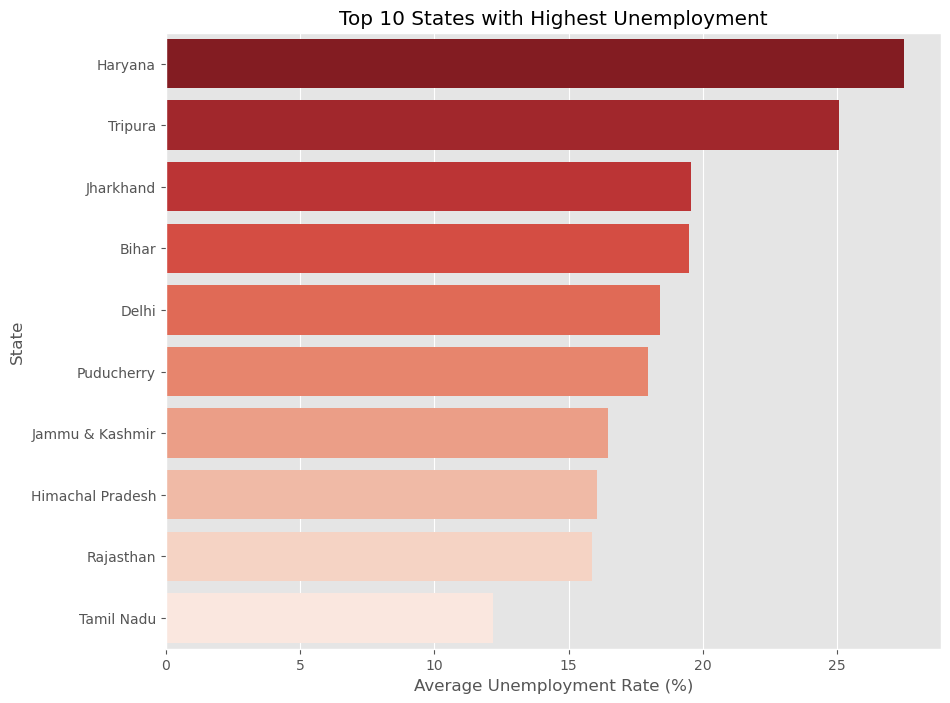

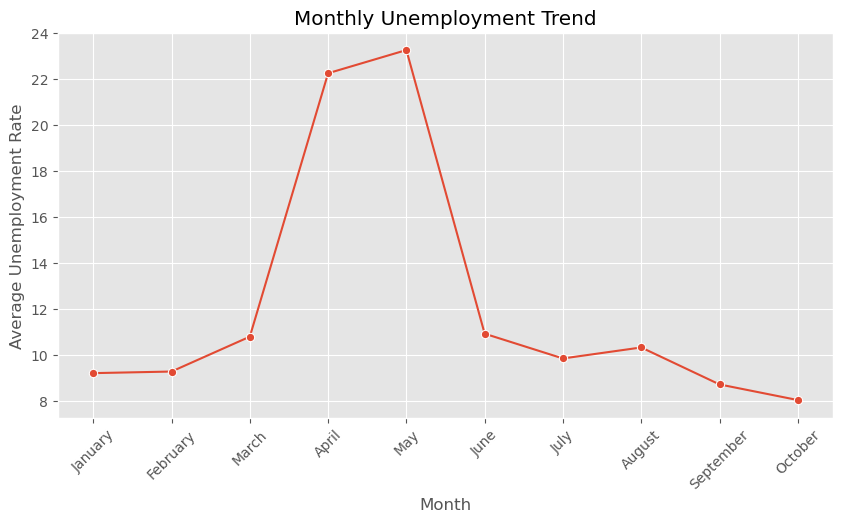

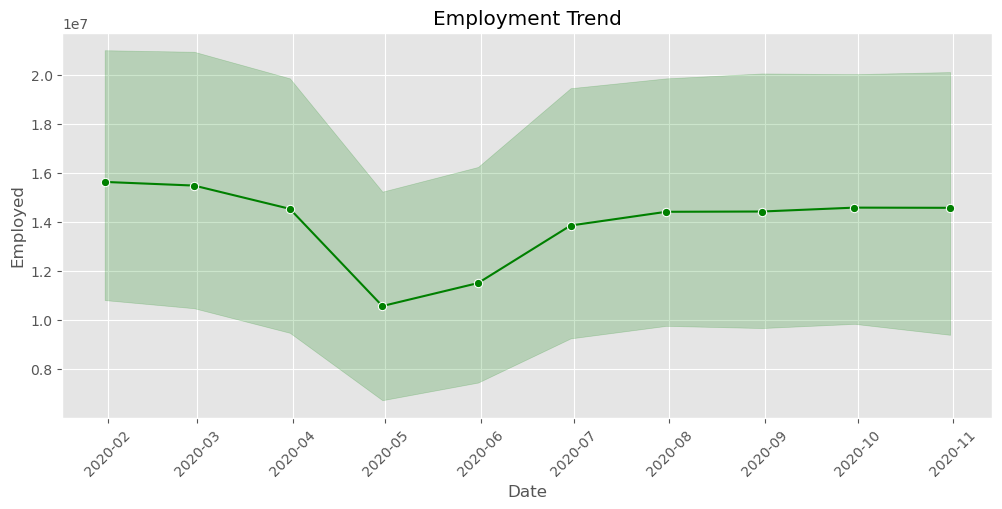

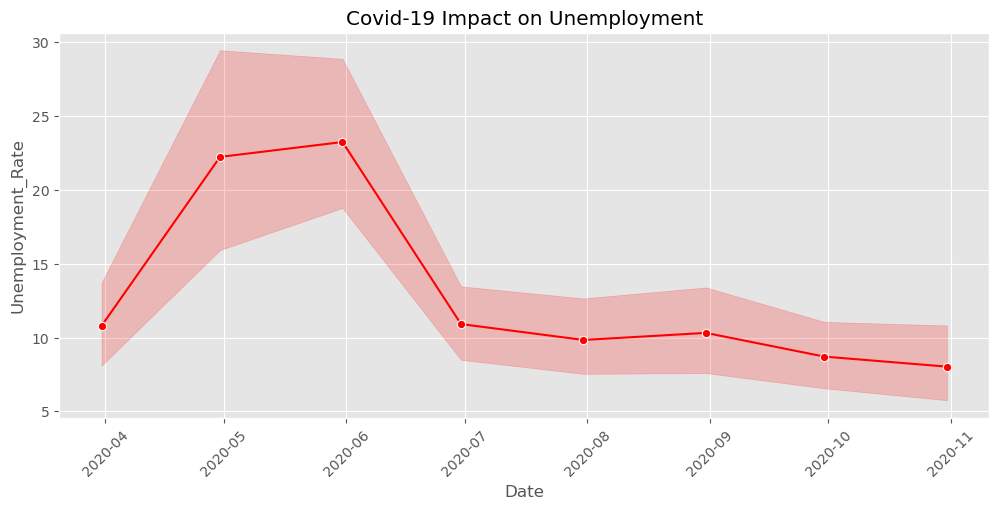

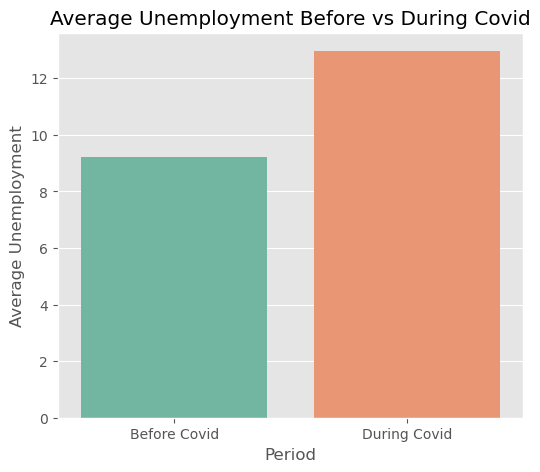

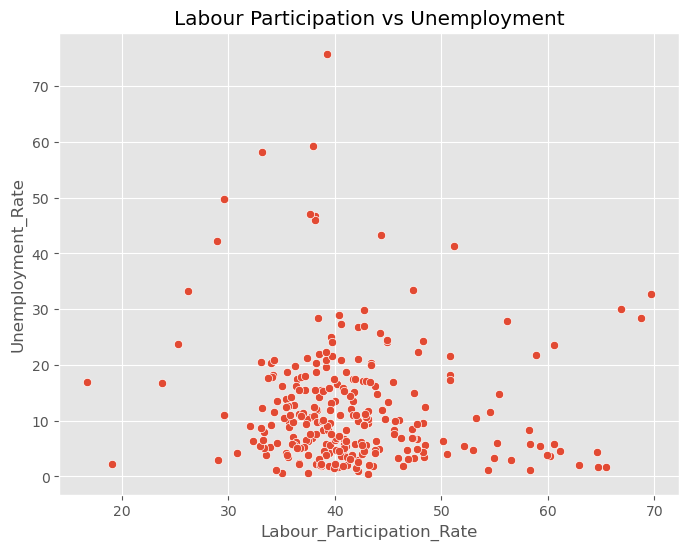

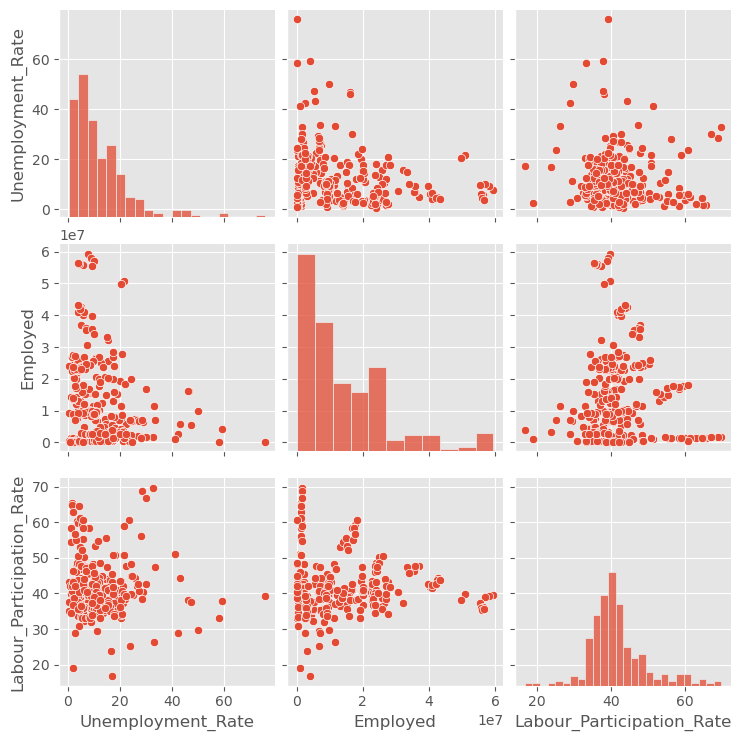

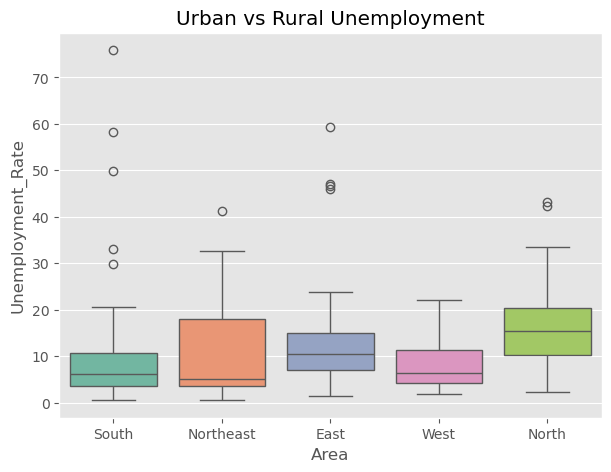


UNEMPLOYMENT ANALYSIS SUMMARY
Total Records : 267
Total States : 27
Average Unemployment Rate : 12.24 %
Highest Unemployment Rate : 75.85 %
Lowest Unemployment Rate : 0.5 %

Top 5 States with Highest Unemployment
State
Haryana      27.477
Tripura      25.055
Jharkhand    19.539
Bihar        19.471
Delhi        18.414
Name: Unemployment_Rate, dtype: float64

Policy Insights
• Covid-19 caused a sharp increase in unemployment.
• Some states consistently experienced higher unemployment.
• Monthly trends indicate seasonal fluctuations.
• Labour participation has a moderate relationship with unemployment.
• Governments should focus on employment generation and skill development.


In [2]:
# ==========================================================
# UNEMPLOYMENT ANALYSIS WITH PYTHON
# Oasis Infobyte Data Science Internship - Task 2
# ==========================================================

# =========================
# Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
%matplotlib inline

# =========================
# Load Dataset
# =========================
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# =========================
# Data Cleaning
# =========================
df.columns = df.columns.str.strip()

rename_dict = {
    "Region": "State",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate"
}

# Rename Area column if available
if "Region.1" in df.columns:
    rename_dict["Region.1"] = "Area"

df.rename(columns=rename_dict, inplace=True)

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# Remove missing values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Extract Month
df["Month"] = df["Date"].dt.month_name()

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# =========================
# Correlation Heatmap
# =========================
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include=np.number)

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# =========================
# Distribution Plot
# =========================
plt.figure(figsize=(8,5))

sns.histplot(df["Unemployment_Rate"],
             bins=20,
             kde=True,
             color="royalblue")

plt.title("Distribution of Unemployment Rate")

plt.show()

# =========================
# Box Plot
# =========================
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Unemployment_Rate"],
            color="orange")

plt.title("Boxplot of Unemployment Rate")

plt.show()

# =========================
# Top 10 States
# =========================
state_avg = df.groupby("State")["Unemployment_Rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(x=state_avg.head(10).values,
            y=state_avg.head(10).index,
            palette="Reds_r")

plt.title("Top 10 States with Highest Unemployment")

plt.xlabel("Average Unemployment Rate (%)")

plt.show()

# =========================
# Monthly Trend
# =========================
monthly = df.groupby("Month")["Unemployment_Rate"].mean()

months = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]

monthly = monthly.reindex(months)

plt.figure(figsize=(10,5))

sns.lineplot(x=monthly.index,
             y=monthly.values,
             marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Unemployment Trend")

plt.xlabel("Month")

plt.ylabel("Average Unemployment Rate")

plt.show()

# =========================
# Employment Trend
# =========================
plt.figure(figsize=(12,5))

sns.lineplot(data=df,
             x="Date",
             y="Employed",
             marker="o",
             color="green")

plt.title("Employment Trend")

plt.xticks(rotation=45)

plt.show()

# =========================
# Covid-19 Impact
# =========================
covid = df[df["Date"] >= "2020-03-01"]

plt.figure(figsize=(12,5))

sns.lineplot(data=covid,
             x="Date",
             y="Unemployment_Rate",
             marker="o",
             color="red")

plt.title("Covid-19 Impact on Unemployment")

plt.xticks(rotation=45)

plt.show()

# =========================
# Before vs During Covid
# =========================
before = df[df["Date"] < "2020-03-01"]["Unemployment_Rate"].mean()
after = df[df["Date"] >= "2020-03-01"]["Unemployment_Rate"].mean()

comparison = pd.DataFrame({
    "Period":["Before Covid","During Covid"],
    "Average Unemployment":[before,after]
})

plt.figure(figsize=(6,5))

sns.barplot(data=comparison,
            x="Period",
            y="Average Unemployment",
            palette="Set2")

plt.title("Average Unemployment Before vs During Covid")

plt.show()

# =========================
# Scatter Plot
# =========================
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="Labour_Participation_Rate",
                y="Unemployment_Rate")

plt.title("Labour Participation vs Unemployment")

plt.show()

# =========================
# Pair Plot
# =========================
sns.pairplot(df[[
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate"
]])

plt.show()

# =========================
# Urban vs Rural (Only if Area exists)
# =========================
if "Area" in df.columns:

    plt.figure(figsize=(7,5))

    sns.boxplot(data=df,
                x="Area",
                y="Unemployment_Rate",
                palette="Set2")

    plt.title("Urban vs Rural Unemployment")

    plt.show()

# =========================
# Final Insights
# =========================
print("\n" + "="*55)
print("UNEMPLOYMENT ANALYSIS SUMMARY")
print("="*55)

print("Total Records :", len(df))
print("Total States :", df["State"].nunique())
print("Average Unemployment Rate :", round(df["Unemployment_Rate"].mean(),2),"%")
print("Highest Unemployment Rate :", round(df["Unemployment_Rate"].max(),2),"%")
print("Lowest Unemployment Rate :", round(df["Unemployment_Rate"].min(),2),"%")

print("\nTop 5 States with Highest Unemployment")
print(state_avg.head())

print("\nPolicy Insights")
print("• Covid-19 caused a sharp increase in unemployment.")
print("• Some states consistently experienced higher unemployment.")
print("• Monthly trends indicate seasonal fluctuations.")
print("• Labour participation has a moderate relationship with unemployment.")
print("• Governments should focus on employment generation and skill development.")
print("="*55)